# Modelo Redes Neuronales LSTM

Modelado utilizando redes neuronales LSTM para modelos multivariante y univariante

## Librerías

Cargamos las librerías para la experimentación

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import tempfile
from pathlib import Path
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM, Dropout, Conv1D
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

## Configuraciones

Definimos las configuraciones para la experimentación

In [18]:
TRAIN_PATH = "../data/conjuntos/datos_entrenamiento.csv"
VAL_PATH = "../data/conjuntos/datos_prueba.csv"
DATE_COL = "FechaMedicion"
TARGET_COL = "Potencia"
PHASE_COL = "Fase"
TEST_SIZE = 6
MLFLOW_URI = "http://vm-dev-docker-1.int.alephsub0.org:5000"
MLFLOW_EXPERIMENT = "TFM_Modelado_LSTM"

LISTA_FASES = [1, 2]

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

lista_regresores = ["Voltaje", "FactorPotencia", "Frecuencia"]

df = (
    pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)
df_val = (
    pd.read_csv(VAL_PATH, parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

print(f"Datos cargados: {df.shape}")
print(f"Fases disponibles: {sorted(df[PHASE_COL].dropna().unique().tolist())}")
print(f"Tracking URI activo: {mlflow.get_tracking_uri()}")

Datos cargados: (7790, 8)
Fases disponibles: [1, 2]
Tracking URI activo: http://vm-dev-docker-1.int.alephsub0.org:5000


In [19]:
semilla = 17
np.random.seed(semilla)
random.seed(semilla)
tf.random.set_seed(semilla)

## Funciones auxiliares

In [20]:
def series_ventana(df: pd.DataFrame, window_size: int, target_col: str, horizonte: int = TEST_SIZE) -> tuple:
    """
    Divide la serie en ventanas de entrada y un objetivo multisalida de `horizonte` pasos.
    """

    x_resultado = []
    y_resultado = []

    indice_columna_objetivo = df.columns.get_loc(target_col)

    limite = len(df) - window_size - horizonte + 1
    for i in range(limite):
        ventana_x = df.iloc[i : i + window_size, :].values
        ventana_y = df.iloc[
            i + window_size : i + window_size + horizonte,
            indice_columna_objetivo,
        ].values
        x_resultado.append(ventana_x)
        y_resultado.append(ventana_y)

    return np.array(x_resultado), np.array(y_resultado)


def evaluar_modelo(model, train_x, train_y, val_x, val_y, test_x, test_y, train_min, train_max):
    """
    Realiza predicciones, descala resultados y calcula métricas.
    """
    y_train_pred = model.predict(train_x)
    y_val_pred = model.predict(val_x)
    y_test_pred = model.predict(test_x)

    factor_escala = train_max - train_min
    offset = train_min

    y_train_pred_unscaled = y_train_pred * factor_escala + offset
    y_val_pred_unscaled = y_val_pred * factor_escala + offset
    y_test_pred_unscaled = y_test_pred * factor_escala + offset

    train_y_unscaled = train_y * factor_escala + offset
    val_y_unscaled = val_y * factor_escala + offset
    test_y_unscaled = test_y * factor_escala + offset

    def calcular_mape(y_real, y_pred):
        denominador = np.abs(y_real) + 1e-9
        return np.mean(np.abs((y_real - y_pred) / denominador)) * 100

    rmse_train = root_mean_squared_error(train_y_unscaled.reshape(-1), y_train_pred_unscaled.reshape(-1))
    mae_train = mean_absolute_error(train_y_unscaled.reshape(-1), y_train_pred_unscaled.reshape(-1))
    mape_train = calcular_mape(train_y_unscaled.reshape(-1), y_train_pred_unscaled.reshape(-1))
    print(f"Train - RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, MAPE: {mape_train:.4f}%")

    rmse_val = root_mean_squared_error(val_y_unscaled.reshape(-1), y_val_pred_unscaled.reshape(-1))
    mae_val = mean_absolute_error(val_y_unscaled.reshape(-1), y_val_pred_unscaled.reshape(-1))
    mape_val = calcular_mape(val_y_unscaled.reshape(-1), y_val_pred_unscaled.reshape(-1))
    print(f"Validation - RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}, MAPE: {mape_val:.4f}%")

    rmse_test = root_mean_squared_error(test_y_unscaled.reshape(-1), y_test_pred_unscaled.reshape(-1))
    mae_test = mean_absolute_error(test_y_unscaled.reshape(-1), y_test_pred_unscaled.reshape(-1))
    mape_test = calcular_mape(test_y_unscaled.reshape(-1), y_test_pred_unscaled.reshape(-1))
    print(f"Test - RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, MAPE: {mape_test:.4f}%")

    return (
        y_train_pred_unscaled,
        y_val_pred_unscaled,
        y_test_pred_unscaled,
        train_y_unscaled,
        val_y_unscaled,
        test_y_unscaled,
        mape_train,
        mape_val,
        mape_test,
    )


def visualizar_predicciones(test_y_unscaled, y_test_pred_unscaled, df_testval, fases, target_col, phase_col, test_size):
    """
    Visualiza las predicciones comparadas con los valores reales para cada fase.
    """
    paso = test_size - 1

    for fase in fases:
        gt_phase = df_testval[df_testval[phase_col] == fase].copy()

        if gt_phase.empty:
            print(f"Fase {fase}: sin datos para visualizar")
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        x_labels = [f"t+{i+1}" for i in range(test_size)]
        x_range = np.arange(test_size)

        y_real_ultimos = test_y_unscaled[-test_size:, :]
        y_pred_ultimos = y_test_pred_unscaled[-test_size:, :]

        ax.plot(x_range, y_real_ultimos[:, paso], label="Valores Reales", marker="o", linewidth=2, markersize=8)
        ax.plot(x_range, y_pred_ultimos[:, paso], label="Predicciones", marker="x", linewidth=2, markersize=8)

        ax.set_title(f"Últimos {test_size} pasos - Fase {fase}")
        ax.set_xlabel("Paso hacia el futuro")
        ax.set_ylabel(target_col)
        ax.set_xticks(x_range)
        ax.set_xticklabels(x_labels)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


def log_figura_mlflow(fig, nombre):
    """Registra una figura de matplotlib en MLflow."""
    mlflow.log_figure(fig, nombre)


def ultimo_valor_history(history_dict, posibles_claves):
    """Obtiene el ultimo valor de la primera clave existente en history."""
    for clave in posibles_claves:
        valores = history_dict.get(clave)
        if valores:
            return float(valores[-1])
    return None


def log_modelo_metadata_mlflow(model, model_builder_name):
    """Registra nombre y arquitectura del modelo en MLflow."""
    mlflow.log_param("model_name", model_builder_name)

    with tempfile.TemporaryDirectory() as temp_dir:
        temp_path = Path(temp_dir)

        model_json_path = temp_path / "model_architecture.json"
        model_json_path.write_text(model.to_json(), encoding="utf-8")
        mlflow.log_artifact(str(model_json_path), artifact_path="model_metadata")

        summary_path = temp_path / "model_summary.txt"
        with open(summary_path, "w", encoding="utf-8") as f:
            model.summary(print_fn=lambda x: f.write(x + "\n"))
        mlflow.log_artifact(str(summary_path), artifact_path="model_metadata")


def registrar_datasets_mlflow(df_train_fase, df_val_fase, train_x, train_y, val_x, val_y, test_x, test_y, fase, window_size):
    """Registra conjuntos de datos como artifacts CSV en MLflow."""
    with tempfile.TemporaryDirectory() as temp_dir:
        temp_path = Path(temp_dir)

        archivos = {
            f"fase_{fase}_train_raw.csv": df_train_fase,
            f"fase_{fase}_val_raw.csv": df_val_fase,
            f"fase_{fase}_train_x.csv": pd.DataFrame(train_x.reshape(train_x.shape[0], -1)),
            f"fase_{fase}_train_y.csv": pd.DataFrame(train_y),
            f"fase_{fase}_val_x.csv": pd.DataFrame(val_x.reshape(val_x.shape[0], -1)),
            f"fase_{fase}_val_y.csv": pd.DataFrame(val_y),
            f"fase_{fase}_test_x.csv": pd.DataFrame(test_x.reshape(test_x.shape[0], -1)),
            f"fase_{fase}_test_y.csv": pd.DataFrame(test_y),
        }

        for nombre_archivo, dataframe in archivos.items():
            ruta_archivo = temp_path / nombre_archivo
            dataframe.to_csv(ruta_archivo, index=False)
            mlflow.log_artifact(str(ruta_archivo), artifact_path="datasets")

        mlflow.log_params({
            f"fase_{fase}_train_rows": len(df_train_fase),
            f"fase_{fase}_val_rows": len(df_val_fase),
            f"fase_{fase}_train_x_rows": train_x.shape[0],
            f"fase_{fase}_val_x_rows": val_x.shape[0],
            f"fase_{fase}_test_x_rows": test_x.shape[0],
            f"fase_{fase}_window_size": window_size,
        })


def preparar_datos(
    df: pd.DataFrame,
    df_val: pd.DataFrame,
    window_size: int,
    target_col: str,
    porcentaje_train: float = 0.5,
    regresors: list = lista_regresores,
) -> tuple:
    """
    Prepara los datos para el modelo LSTM con horizonte de prediccion de TEST_SIZE pasos.
    """

    df_modelo = df.drop(columns=[DATE_COL], errors="ignore").copy()
    df_val = df_val.drop(columns=[DATE_COL], errors="ignore").copy()

    df_modelo = df_modelo[regresors + [target_col]]
    df_val = df_val[regresors + [target_col]]

    train_df = df_modelo

    n_val = len(df_val)
    split_idx = int(n_val * porcentaje_train)
    val_df = df_val.iloc[:split_idx]
    test_df = df_val.iloc[split_idx:]

    train_min = train_df.min()
    train_max = train_df.max()
    rango = (train_max - train_min).replace(0, 1)

    train_df = (train_df - train_min) / rango
    val_df = (val_df - train_min) / rango
    test_df = (test_df - train_min) / rango

    train_x, train_y = series_ventana(train_df, window_size, target_col, TEST_SIZE)
    print("Dimensiones de X:", train_x.shape)
    print("Dimensiones de Y:", train_y.shape)

    val_x, val_y = series_ventana(val_df, window_size, target_col, TEST_SIZE)
    print("Dimensiones de X:", val_x.shape)
    print("Dimensiones de Y:", val_y.shape)

    test_x, test_y = series_ventana(test_df, window_size, target_col, TEST_SIZE)
    print("Dimensiones de X:", test_x.shape)
    print("Dimensiones de Y:", test_y.shape)

    return (
        train_x,
        train_y,
        val_x,
        val_y,
        test_x,
        test_y,
        train_min[target_col],
        train_max[target_col],
    )


def modelar_y_registrar_fase(fase, window_size, model_builder):
    """Entrena, evalúa y registra en MLflow un modelo para una fase."""
    df_train_fase = df[df[PHASE_COL] == fase].reset_index(drop=True)
    df_testval_fase = df_val[df_val[PHASE_COL] == fase].reset_index(drop=True)

    (
        train_x,
        train_y,
        val_x,
        val_y,
        test_x,
        test_y,
        train_min,
        train_max,
    ) = preparar_datos(df_train_fase, df_testval_fase, window_size, TARGET_COL, 0.5)

    model = model_builder(train_x.shape[1:], TEST_SIZE)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )

    with mlflow.start_run(run_name=f"fase_{fase}_window_{window_size}", nested=True):
        mlflow.log_params({
            "fase": fase,
            "window_size": window_size,
            "target_col": TARGET_COL,
            "phase_col": PHASE_COL,
            "test_size": TEST_SIZE,
            "epochs": 30,
            "batch_size": 32,
            "patience": 5,
            "optimizer": "adam",
            "seed": semilla,
            "model_name": model_builder.__name__,
        })

        log_modelo_metadata_mlflow(model, model_builder.__name__)

        registrar_datasets_mlflow(
            df_train_fase,
            df_testval_fase,
            train_x,
            train_y,
            val_x,
            val_y,
            test_x,
            test_y,
            fase,
            window_size,
        )

        history = model.fit(
            train_x,
            train_y,
            epochs=30,
            batch_size=32,
            validation_data=(val_x, val_y),
            callbacks=[early_stopping],
            verbose=0,
        )

        metricas_entrenamiento = {
            "loss_final": ultimo_valor_history(history.history, ["loss"]),
            "val_loss_final": ultimo_valor_history(history.history, ["val_loss"]),
            "mae_final": ultimo_valor_history(history.history, ["mae", "mean_absolute_error"]),
            "val_mae_final": ultimo_valor_history(history.history, ["val_mae", "val_mean_absolute_error"]),
            "mse_final": ultimo_valor_history(history.history, ["mse", "mean_squared_error"]),
            "val_mse_final": ultimo_valor_history(history.history, ["val_mse", "val_mean_squared_error"]),
            "epochs_run": float(len(history.history.get("loss", []))),
        }
        mlflow.log_metrics({k: v for k, v in metricas_entrenamiento.items() if v is not None})

        y_train_pred_unscaled, y_val_pred_unscaled, y_test_pred_unscaled, train_y_unscaled, val_y_unscaled, test_y_unscaled, mape_train, mape_val, mape_test = evaluar_modelo(
            model,
            train_x,
            train_y,
            val_x,
            val_y,
            test_x,
            test_y,
            train_min,
            train_max,
        )

        rmse_train = root_mean_squared_error(train_y_unscaled.reshape(-1), y_train_pred_unscaled.reshape(-1))
        mae_train = mean_absolute_error(train_y_unscaled.reshape(-1), y_train_pred_unscaled.reshape(-1))
        rmse_val = root_mean_squared_error(val_y_unscaled.reshape(-1), y_val_pred_unscaled.reshape(-1))
        mae_val = mean_absolute_error(val_y_unscaled.reshape(-1), y_val_pred_unscaled.reshape(-1))
        rmse_test = root_mean_squared_error(test_y_unscaled.reshape(-1), y_test_pred_unscaled.reshape(-1))
        mae_test = mean_absolute_error(test_y_unscaled.reshape(-1), y_test_pred_unscaled.reshape(-1))

        mlflow.log_metrics({
            "rmse_train": float(rmse_train),
            "mae_train": float(mae_train),
            "mape_train": float(mape_train),
            "rmse_val": float(rmse_val),
            "mae_val": float(mae_val),
            "mape_val": float(mape_val),
            "rmse_test": float(rmse_test),
            "mae_test": float(mae_test),
            "mape_test": float(mape_test),
        })

        fig, ax = plt.subplots(figsize=(10, 6))
        x_labels = [f"t+{i+1}" for i in range(TEST_SIZE)]
        x_range = np.arange(TEST_SIZE)
        paso = TEST_SIZE - 1
        y_real_ultimos = test_y_unscaled[-TEST_SIZE:, :]
        y_pred_ultimos = y_test_pred_unscaled[-TEST_SIZE:, :]
        y_real_evaluacion = y_real_ultimos[:, paso].reshape(-1)
        y_pred_evaluacion = y_pred_ultimos[:, paso].reshape(-1)

        def calcular_mape_evaluacion(y_real, y_pred):
            denominador = np.abs(y_real) + 1e-9
            return np.mean(np.abs((y_real - y_pred) / denominador)) * 100

        rmse_evaluacion = root_mean_squared_error(y_real_evaluacion, y_pred_evaluacion)
        mae_evaluacion = mean_absolute_error(y_real_evaluacion, y_pred_evaluacion)
        mape_evaluacion = calcular_mape_evaluacion(y_real_evaluacion, y_pred_evaluacion)

        mlflow.log_metrics({
            "rmse_evaluacion": float(rmse_evaluacion),
            "mae_evaluacion": float(mae_evaluacion),
            "mape_evaluacion": float(mape_evaluacion),
        })

        ax.plot(x_range, y_real_evaluacion, label="Valores Reales", marker="o", linewidth=2, markersize=8)
        ax.plot(x_range, y_pred_evaluacion, label="Predicciones", marker="x", linewidth=2, markersize=8)
        ax.set_title(f"Últimos {TEST_SIZE} pasos - Fase {fase}")
        ax.set_xlabel("Paso hacia el futuro")
        ax.set_ylabel(TARGET_COL)
        ax.set_xticks(x_range)
        ax.set_xticklabels(x_labels)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        log_figura_mlflow(fig, f"fase_{fase}_predicciones.png")
        plt.close(fig)

        with tempfile.TemporaryDirectory() as temp_dir:
            temp_path = Path(temp_dir)
            temp_csv = temp_path / f"fase_{fase}_comparacion.csv"
            pd.DataFrame({
                "real": y_real_ultimos[:, paso],
                "predicho": y_pred_ultimos[:, paso],
            }).to_csv(temp_csv, index=False)
            mlflow.log_artifact(str(temp_csv), artifact_path="datasets")

            model_path = temp_path / "model.keras"
            model.save(model_path)
            mlflow.log_artifact(str(model_path), artifact_path="model")

    resultados = {
        "model": model,
        "test_y_unscaled": test_y_unscaled,
        "y_test_pred_unscaled": y_test_pred_unscaled,
        "df_testval": df_testval_fase,
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "mape_test": mape_test,
        "rmse_evaluacion": rmse_evaluacion,
        "mae_evaluacion": mae_evaluacion,
        "mape_evaluacion": mape_evaluacion,
    }

    return model, resultados


def entrenar_modelos_por_fase(window_size, model_builder):
    """Entrena modelos LSTM para cada fase y retorna resultados."""
    modelos = {}
    resultados = {}

    with mlflow.start_run(run_name=f"window_{window_size}_model_builder_{model_builder.__name__}"):
        mlflow.log_params({
            "window_size": window_size,
            "test_size": TEST_SIZE,
            "target_col": TARGET_COL,
            "phase_col": PHASE_COL,
            "num_fases": len(LISTA_FASES),
            "seed": semilla,
            "tracking_uri": MLFLOW_URI,
            "experiment_name": MLFLOW_EXPERIMENT,
            "regresores": ",".join(lista_regresores),
            "train_path": TRAIN_PATH,
            "val_path": VAL_PATH,
        })

        mlflow.log_params({
            "df_train_rows": len(df),
            "df_val_rows": len(df_val),
            "fases": ",".join(map(str, LISTA_FASES)),
        })

        for fase in LISTA_FASES:
            print(f"\n{'='*60}")
            print(f"MODELADO FASE {fase}")
            print(f"{'='*60}\n")

            model, resultado_fase = modelar_y_registrar_fase(fase, window_size, model_builder)
            modelos[fase] = model
            resultados[fase] = resultado_fase

    return modelos, resultados

## Preparación de los datos

In [21]:
df.head()

,Fase,FechaMedicion,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia,EnergiaActiva
0,1,2026-02-15 13:10:00,119.810,3.860,405.890,0.877,59.970,0.159
1,2,2026-02-15 13:10:00,115.070,0.869,61.620,0.616,59.930,369.819
2,1,2026-02-15 13:20:00,120.038,3.536,369.512,0.874,59.962,0.222
3,2,2026-02-15 13:20:00,115.762,0.911,65.475,0.620,59.962,369.830
4,1,2026-02-15 13:30:00,118.860,4.576,499.550,0.909,59.970,0.297


In [22]:
df_train_f1 = df[df[PHASE_COL] == 1].reset_index(drop=True)
df_train_f2 = df[df[PHASE_COL] == 2].reset_index(drop=True)
df_testval_f1 = df_val[df_val[PHASE_COL] == 1].reset_index(drop=True)
df_testval_f2 = df_val[df_val[PHASE_COL] == 2].reset_index(drop=True)

## Modelado

Definimos las arquitecturas de modelos a evaluar

In [23]:
def modelo_lstm_base(input_shape, output_size):
    """
    Crea y compila un modelo LSTM.
    
    Parámetros:
    - input_shape: tupla (window_size, num_features)
    - output_size: número de pasos a predecir
    
    Retorna:
    - model: modelo compilado
    """
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dropout(0.2),
        Dense(output_size)
    ])
    
    model.compile(optimizer="adam", loss="mse", metrics=["mae", "mse"])
    return model

def modelo_referencia_cnn_lstm(input_shape, output_size):
    """
    Crea y compila un modelo CNN+LSTM.
    
    Parámetros:
    - input_shape: tupla (window_size, num_features)
    - output_size: número de pasos a predecir
    
    Retorna:
    - model: modelo compilado
    """
    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(Conv1D(64, kernel_size=3, strides=1, activation='relu',padding='same'))
    model.add(Conv1D(128, kernel_size=3, strides=1, activation='relu', padding='same'))
    model.add(Conv1D(256, kernel_size=3, strides=1, activation='relu', padding='same'))
    model.add(Conv1D(128, kernel_size=3, strides=1, activation='relu', padding='same'))
    model.add(Conv1D(64, kernel_size=3, strides=1, activation='relu', padding='same'))

    model.add(LSTM(64, return_sequences=True))
    model.add(LSTM(128, return_sequences=True))
    model.add(LSTM(256, return_sequences=True))
    model.add(LSTM(128, return_sequences=True))
    model.add(LSTM(64, return_sequences=True))

    model.add(LSTM(output_size, return_sequences=False))

    model.add(Dropout(0.1))

    model.add(Dense(output_size))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model


################################################################################
ENTRENAMIENTO MODELO LSTM - Ventana 6
################################################################################


------------------------------------------------------------
Modelo: modelo_lstm_base
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3884, 6, 4)
Dimensiones de Y: (3884, 6)
Dimensiones de X: (1936, 6, 4)
Dimensiones de Y: (1936, 6)
Dimensiones de X: (1937, 6, 4)
Dimensiones de Y: (1937, 6)


Restoring model weights from the end of the best epoch: 30.
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Train - RMSE: 176.3927, MAE: 113.9146, MAPE: 33.2782%
Validation - RMSE: 188.3476, MAE: 121.2193, MAPE: 35.3456%
Test - RMSE: 163.9784, MAE: 106.8885, MAPE: 31.2565%
🏃 View run fase_1_window_6 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/d4f56c7439544523ac95733d530eead7
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3884, 6, 4)
Dimensiones de Y: (3884, 6)
Dimensiones de X: (1936, 6, 4)
Dimensiones de Y: (1936, 6)
Dimensiones de X: (1937, 6, 4)
Dimensiones de Y: (1937, 6)


Restoring model weights from the end of the best epoch: 30.
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train - RMSE: 129.5419, MAE: 61.0997, MAPE: 57.3950%
Validation - RMSE: 160.0627, MAE: 76.9631, MAPE: 84.6730%
Test - RMSE: 89.6699, MAE: 45.5113, MAPE: 30.2684%
🏃 View run fase_2_window_6 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/b70a97dba2094ce9a87cc8d6688e9760
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_6_model_builder_modelo_lstm_base at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/79a649548bd34c8aa7af313a52ac0d12
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



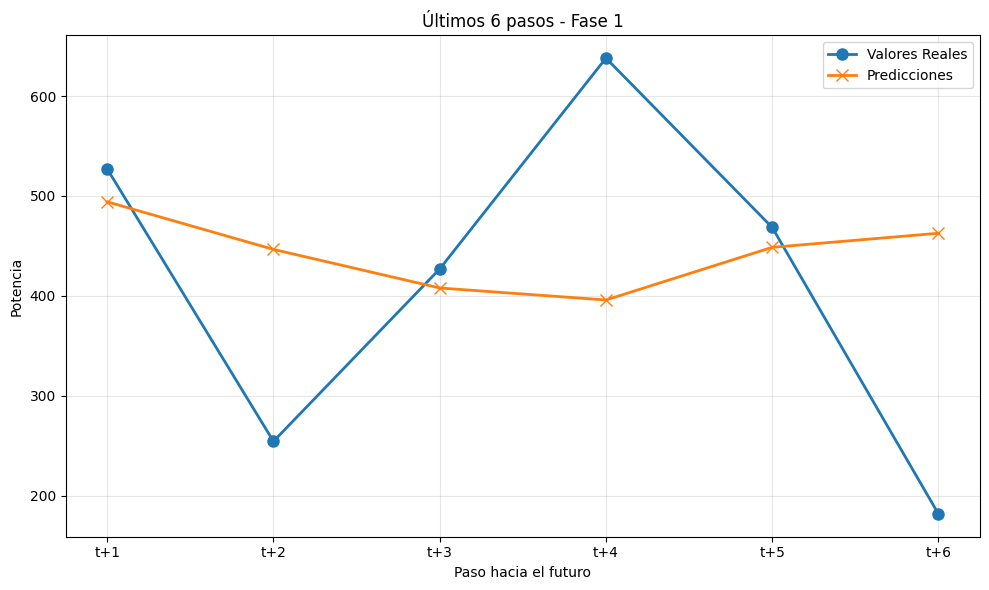

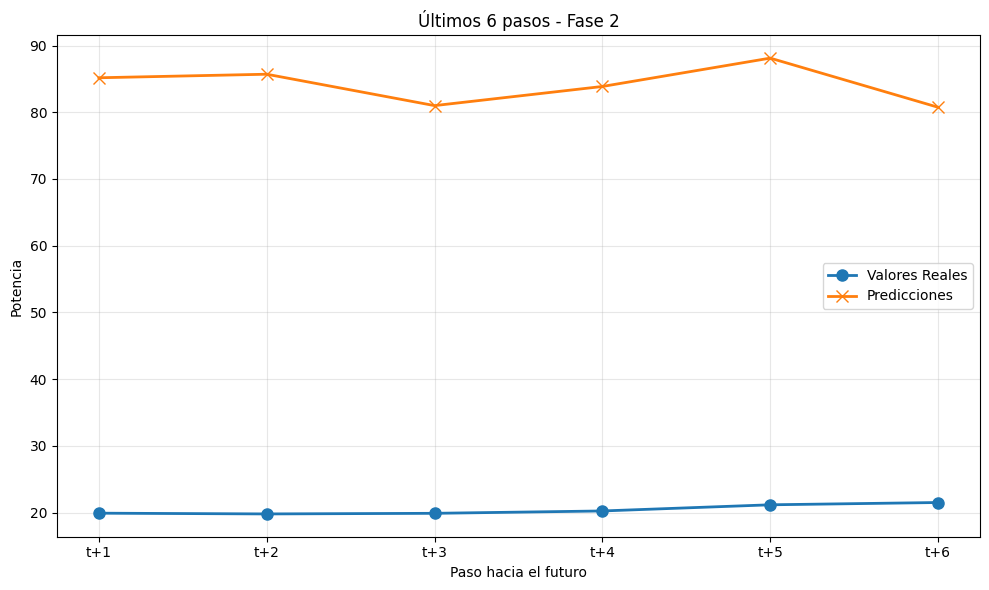


------------------------------------------------------------
Modelo: modelo_referencia_cnn_lstm
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3884, 6, 4)
Dimensiones de Y: (3884, 6)
Dimensiones de X: (1936, 6, 4)
Dimensiones de Y: (1936, 6)
Dimensiones de X: (1937, 6, 4)
Dimensiones de Y: (1937, 6)


Restoring model weights from the end of the best epoch: 30.
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train - RMSE: 173.0164, MAE: 115.5111, MAPE: 34.4052%
Validation - RMSE: 182.2019, MAE: 120.5677, MAPE: 35.7027%
Test - RMSE: 163.6985, MAE: 110.7189, MAPE: 33.1485%
🏃 View run fase_1_window_6 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/c928375e45da413dba44e49ecbff3b98
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3884, 6, 4)
Dimensiones de Y: (3884, 6)
Dimensiones de X: (1936, 6, 4)
Dimensiones de Y: (1936, 6)
Dimensiones de X: (1937, 6, 4)
Dimensiones de Y: (1937, 6)


Restoring model weights from the end of the best epoch: 29.
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train - RMSE: 125.6106, MAE: 57.9897, MAPE: 50.4487%
Validation - RMSE: 155.1717, MAE: 71.9376, MAPE: 72.8600%
Test - RMSE: 87.0120, MAE: 44.3316, MAPE: 28.2256%
🏃 View run fase_2_window_6 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/c6a1559b52724c53ad2754fd2f0e3451
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_6_model_builder_modelo_referencia_cnn_lstm at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/ce081c91b0e44223974ead35e141e299
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



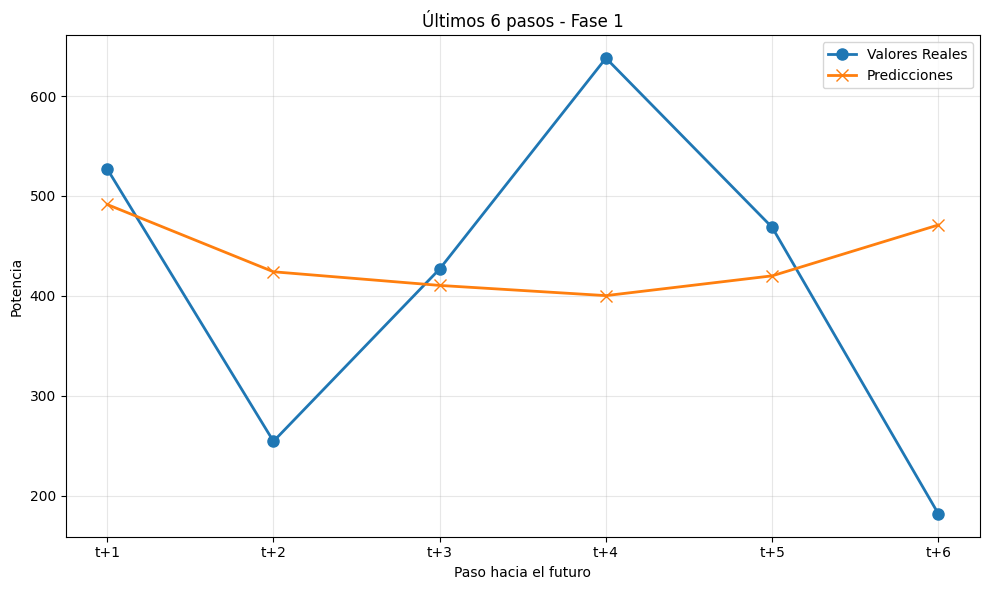

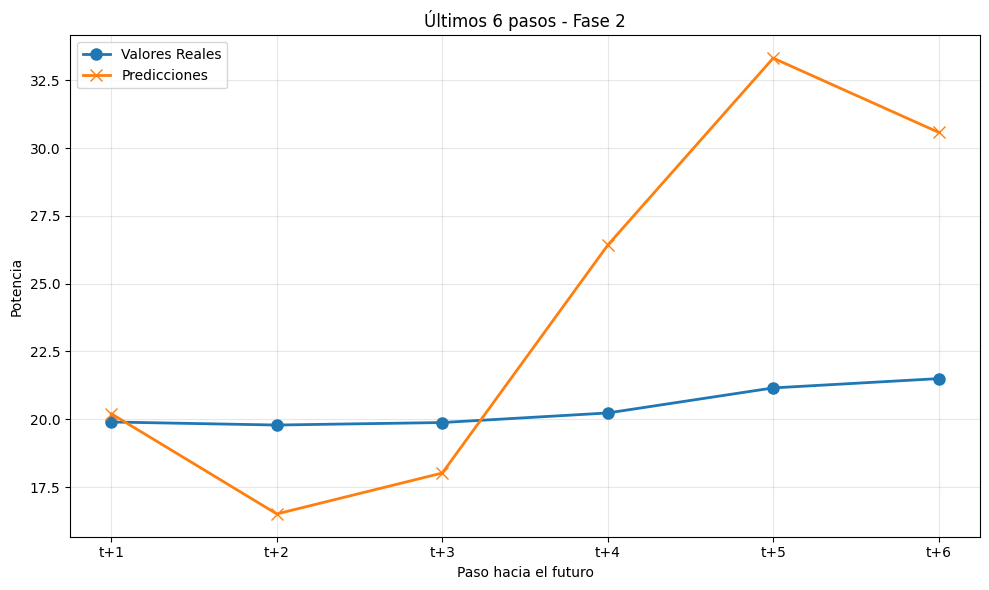


################################################################################
ENTRENAMIENTO MODELO LSTM - Ventana 36
################################################################################


------------------------------------------------------------
Modelo: modelo_lstm_base
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3854, 36, 4)
Dimensiones de Y: (3854, 6)
Dimensiones de X: (1906, 36, 4)
Dimensiones de Y: (1906, 6)
Dimensiones de X: (1907, 36, 4)
Dimensiones de Y: (1907, 6)


Restoring model weights from the end of the best epoch: 29.
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Train - RMSE: 175.4047, MAE: 116.1157, MAPE: 34.5921%
Validation - RMSE: 186.6688, MAE: 123.2118, MAPE: 36.7284%
Test - RMSE: 164.8137, MAE: 109.9144, MAPE: 32.5386%
🏃 View run fase_1_window_36 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/b131cfa721b04b60b51e1890d568e5f0
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3854, 36, 4)
Dimensiones de Y: (3854, 6)
Dimensiones de X: (1906, 36, 4)
Dimensiones de Y: (1906, 6)
Dimensiones de X: (1907, 36, 4)
Dimensiones de Y: (1907, 6)


Restoring model weights from the end of the best epoch: 30.
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Train - RMSE: 115.3554, MAE: 57.3043, MAPE: 56.4321%
Validation - RMSE: 136.5574, MAE: 66.5616, MAPE: 80.9997%
Test - RMSE: 90.7916, MAE: 48.9806, MAPE: 32.0279%
🏃 View run fase_2_window_36 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/516b68de2275491999b987c84313ef10
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_36_model_builder_modelo_lstm_base at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/c4ffb8f417094e5e9945c39a400bf609
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



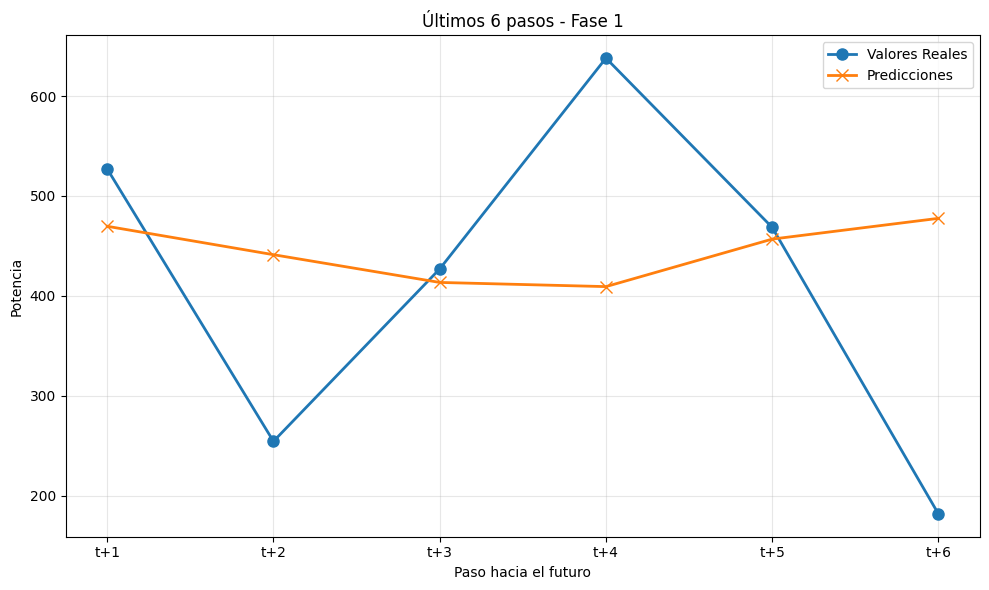

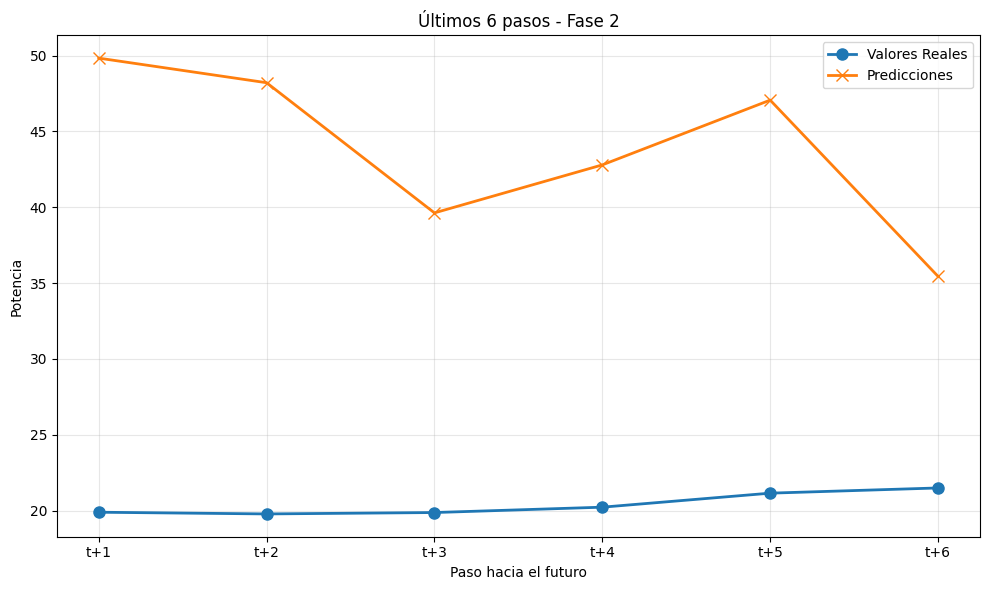


------------------------------------------------------------
Modelo: modelo_referencia_cnn_lstm
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3854, 36, 4)
Dimensiones de Y: (3854, 6)
Dimensiones de X: (1906, 36, 4)
Dimensiones de Y: (1906, 6)
Dimensiones de X: (1907, 36, 4)
Dimensiones de Y: (1907, 6)


Restoring model weights from the end of the best epoch: 30.
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Train - RMSE: 164.6328, MAE: 111.3132, MAPE: 33.5084%
Validation - RMSE: 170.6013, MAE: 115.1061, MAPE: 34.8170%
Test - RMSE: 159.7653, MAE: 108.4451, MAPE: 32.3366%
🏃 View run fase_1_window_36 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/f118572c212f4b8ca2447f3d86db6afa
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3854, 36, 4)
Dimensiones de Y: (3854, 6)
Dimensiones de X: (1906, 36, 4)
Dimensiones de Y: (1906, 6)
Dimensiones de X: (1907, 36, 4)
Dimensiones de Y: (1907, 6)


Restoring model weights from the end of the best epoch: 30.
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Train - RMSE: 108.6142, MAE: 55.2750, MAPE: 57.3667%
Validation - RMSE: 130.7574, MAE: 64.9810, MAPE: 82.1654%
Test - RMSE: 82.0944, MAE: 46.3833, MAPE: 32.5796%
🏃 View run fase_2_window_36 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/4603b098645447abb610db94557f65ba
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_36_model_builder_modelo_referencia_cnn_lstm at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/657913a7e1a54f5284b1c67b6121c99f
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



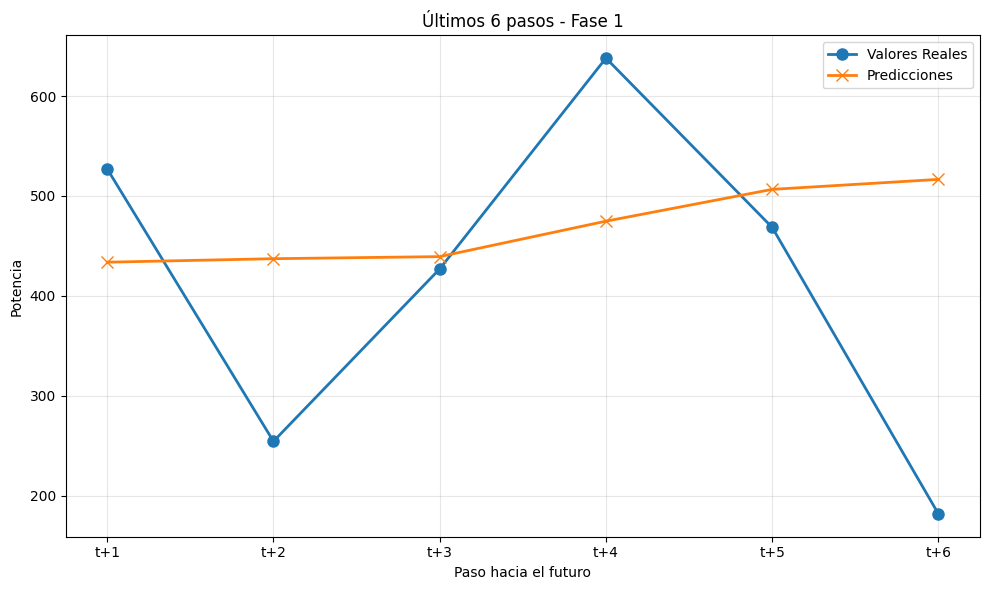

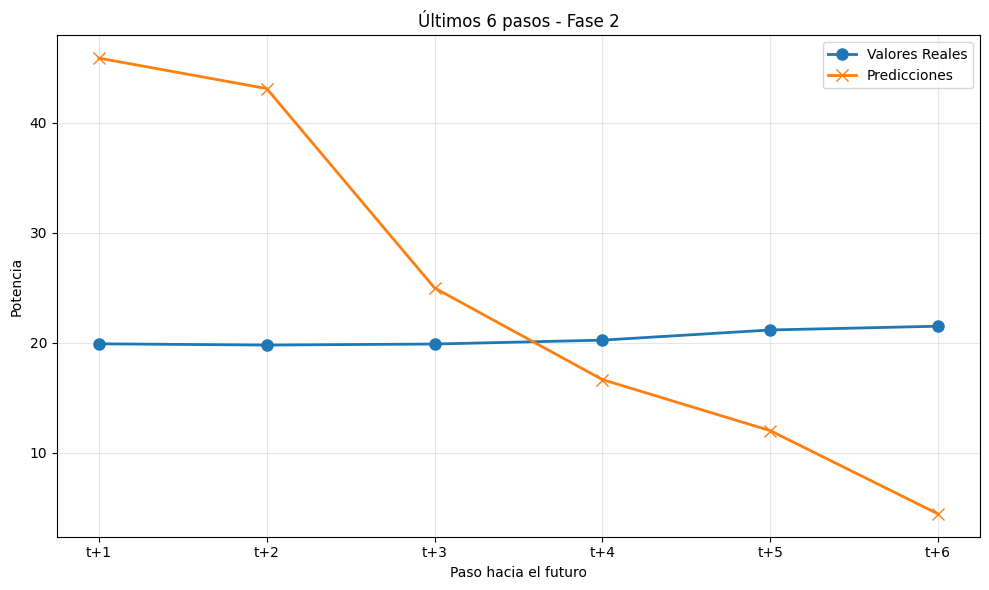


################################################################################
ENTRENAMIENTO MODELO LSTM - Ventana 72
################################################################################


------------------------------------------------------------
Modelo: modelo_lstm_base
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3818, 72, 4)
Dimensiones de Y: (3818, 6)
Dimensiones de X: (1870, 72, 4)
Dimensiones de Y: (1870, 6)
Dimensiones de X: (1871, 72, 4)
Dimensiones de Y: (1871, 6)


Restoring model weights from the end of the best epoch: 27.
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Train - RMSE: 175.2987, MAE: 112.1022, MAPE: 32.3848%
Validation - RMSE: 187.2820, MAE: 119.8485, MAPE: 34.6569%
Test - RMSE: 163.3294, MAE: 104.6752, MAPE: 30.1904%
🏃 View run fase_1_window_72 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/12f9a19baf9e4c1697e3b43caf9a3ad7
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3818, 72, 4)
Dimensiones de Y: (3818, 6)
Dimensiones de X: (1870, 72, 4)
Dimensiones de Y: (1870, 6)
Dimensiones de X: (1871, 72, 4)
Dimensiones de Y: (1871, 6)


Restoring model weights from the end of the best epoch: 30.
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Train - RMSE: 115.5357, MAE: 56.1188, MAPE: 51.8167%
Validation - RMSE: 137.6020, MAE: 64.5711, MAPE: 73.1634%
Test - RMSE: 90.5650, MAE: 48.5459, MAPE: 30.3808%
🏃 View run fase_2_window_72 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/dc089b4e629c4d4e8c779e1ec6f94aa9
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_72_model_builder_modelo_lstm_base at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/42e0263e9120437ba6d411180181e11a
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



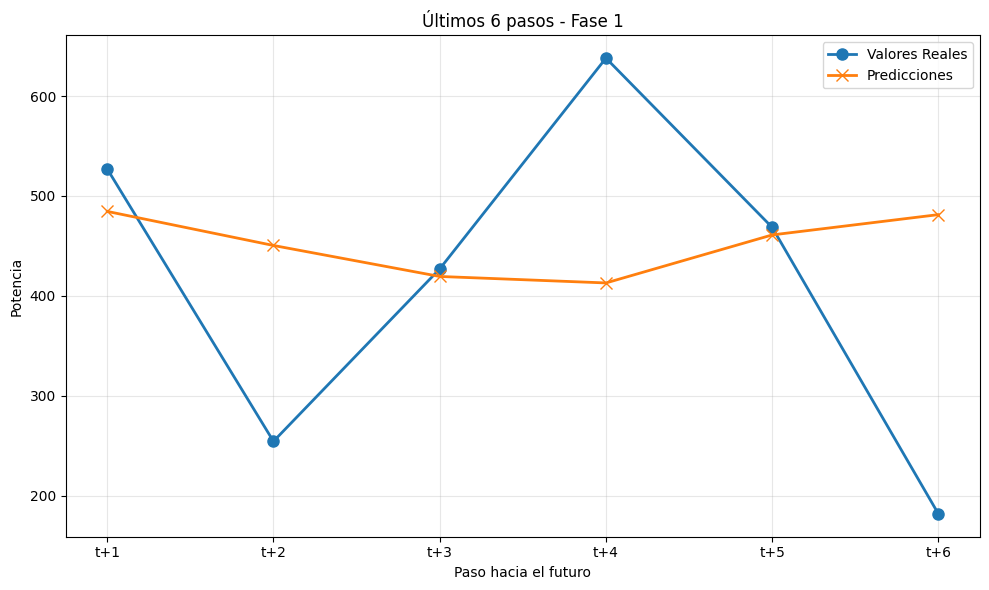

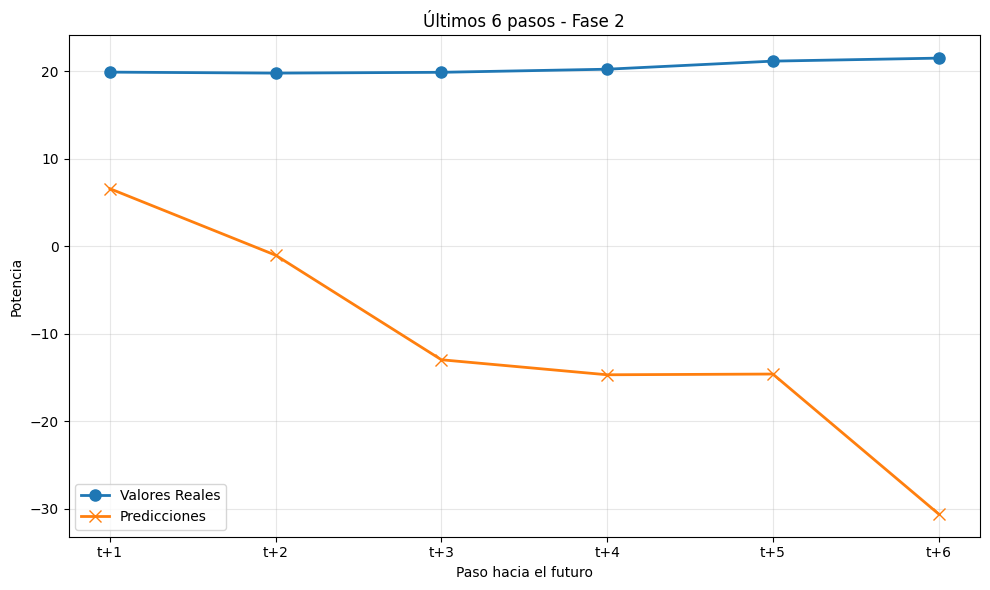


------------------------------------------------------------
Modelo: modelo_referencia_cnn_lstm
------------------------------------------------------------


MODELADO FASE 1

Dimensiones de X: (3818, 72, 4)
Dimensiones de Y: (3818, 6)
Dimensiones de X: (1870, 72, 4)
Dimensiones de Y: (1870, 6)
Dimensiones de X: (1871, 72, 4)
Dimensiones de Y: (1871, 6)


Restoring model weights from the end of the best epoch: 30.
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Train - RMSE: 167.5700, MAE: 102.6178, MAPE: 28.0316%
Validation - RMSE: 175.4881, MAE: 107.7077, MAPE: 29.4362%
Test - RMSE: 159.7995, MAE: 97.6845, MAPE: 26.6984%
🏃 View run fase_1_window_72 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/50b1d71032ff4b4187d46b81d98268ac
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

MODELADO FASE 2

Dimensiones de X: (3818, 72, 4)
Dimensiones de Y: (3818, 6)
Dimensiones de X: (1870, 72, 4)
Dimensiones de Y: (1870, 6)
Dimensiones de X: (1871, 72, 4)
Dimensiones de Y: (1871, 6)


Restoring model weights from the end of the best epoch: 30.
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Train - RMSE: 88.3998, MAE: 50.7505, MAPE: 54.7008%
Validation - RMSE: 102.0026, MAE: 56.7378, MAPE: 77.0174%
Test - RMSE: 73.9222, MAE: 45.5483, MAPE: 32.2606%
🏃 View run fase_2_window_72 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/1ca360115b514434b934f4aeff47b1af
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7
🏃 View run window_72_model_builder_modelo_referencia_cnn_lstm at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7/runs/c95e80c4bde44468a900094e460e778b
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/7

VISUALIZACIÓN DE RESULTADOS



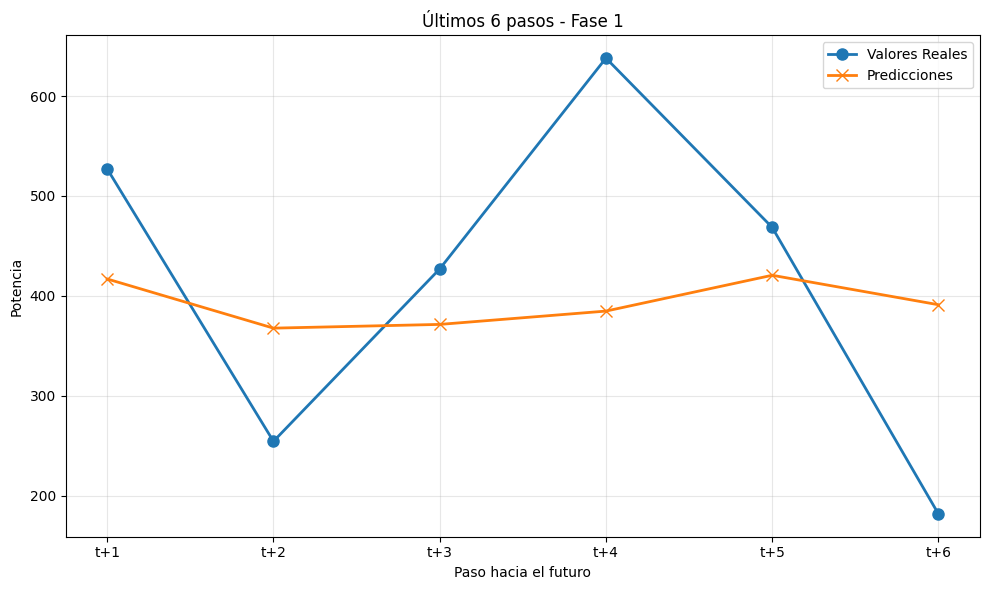

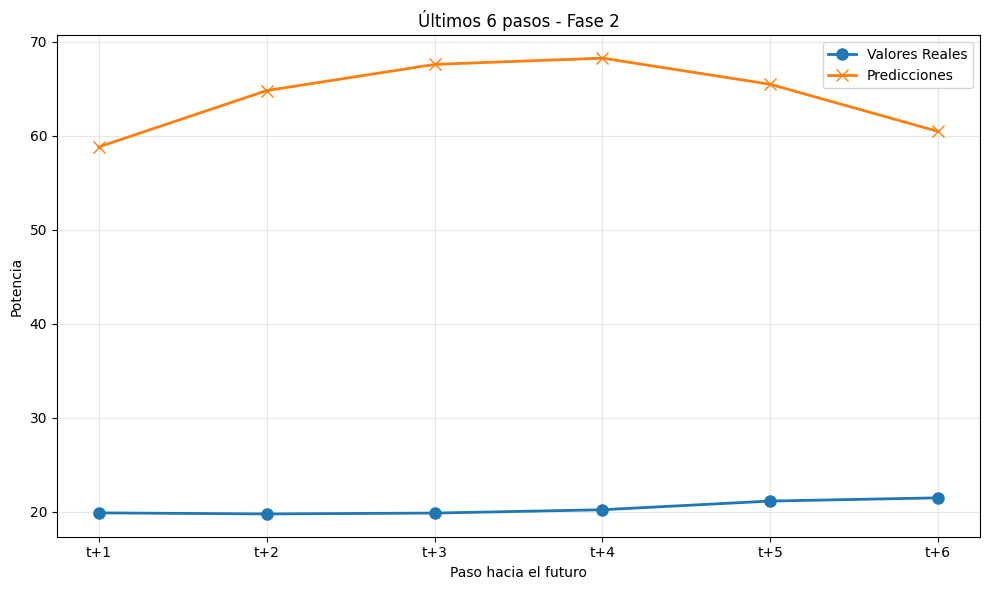

In [24]:
def modelo_lstm_base(input_shape, output_size):
    """
    Crea y compila un modelo LSTM.

    Parámetros:
    - input_shape: tupla (window_size, num_features)
    - output_size: número de pasos a predecir

    Retorna:
    - model: modelo compilado
    """
    model = Sequential(
        [Input(shape=input_shape), LSTM(64), Dropout(0.2), Dense(output_size)]
    )

    model.compile(optimizer="adam", loss="mse", metrics=["mae", "mse"])
    return model


def modelo_referencia_cnn_lstm(input_shape, output_size):
    """
    Crea y compila un modelo CNN+LSTM.

    Parámetros:
    - input_shape: tupla (window_size, num_features)
    - output_size: número de pasos a predecir

    Retorna:
    - model: modelo compilado
    """
    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(Conv1D(64, kernel_size=3, strides=1, activation="relu", padding="same"))
    model.add(LSTM(64, return_sequences=True))

    model.add(LSTM(output_size, return_sequences=False))

    model.add(Dropout(0.1))

    model.add(Dense(output_size))

    model.compile(optimizer="adam", loss="mse", metrics=["mae", "mse"])
    return model


lista_ventanas = [6, 36, 72]
lista_modelos = [modelo_lstm_base, modelo_referencia_cnn_lstm]

# Entrenar modelos para cada fase y obtener resultados
for window_size in lista_ventanas:
    print(f"\n{'#'*80}")
    print(f"ENTRENAMIENTO MODELO LSTM - Ventana {window_size}")
    print(f"{'#'*80}\n")
    for model_selection in lista_modelos:
        print(f"\n{'-'*60}")
        print(f"Modelo: {model_selection.__name__}")
        print(f"{'-'*60}\n")

        modelos, resultados = entrenar_modelos_por_fase(
            window_size=window_size, model_builder=model_selection
        )

        # Visualizar predicciones de ambas fases
        print(f"\n{'='*60}")
        print("VISUALIZACIÓN DE RESULTADOS")
        print(f"{'='*60}\n")

        for fase in LISTA_FASES:
            if fase in resultados:
                visualizar_predicciones(
                    resultados[fase]["test_y_unscaled"],
                    resultados[fase]["y_test_pred_unscaled"],
                    resultados[fase]["df_testval"],
                    [fase],
                    TARGET_COL,
                    PHASE_COL,
                    TEST_SIZE,
                )